# Inference: Anomaly Detection

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../.."))
import numpy as np
import matplotlib.pyplot as plt
from src import load_smd, load_smd_npz, load_checkpoint, evaluate, detect


## 1. Load Data & Model

In [2]:
DATA_PATH = load_smd(
    data_dir="../../assets/data/ServerMachineDataset",
    output_path="../../assets/data/smd/smd_processed_data.npz",
)


Already exists: ../../assets/data/smd/smd_processed_data.npz (delete to re-process)


In [3]:
train_loader, val_loader, test_loader, meta = load_smd_npz(
    DATA_PATH, batch_size=64
)

print(f"Features: {meta['n_features']}  |  Seq len: {meta['seq_len']}")
print(f"Test set: {'yes' if meta['has_test'] else 'no'}")

Features: 38  |  Seq len: 100
Test set: yes


In [7]:
# ── Pick ONE of these (match your training notebook) ──

#Lightweight checkpoint
CHECKPOINT = "../../checkpoints/smd/lightweight/best_model.pt"
MODEL_TYPE = "lightweight"

# #Full checkpoint (uncomment to use)
# CHECKPOINT = "../../checkpoints/smd/full/best_model.pt"
# MODEL_TYPE = "full"

model = load_checkpoint(
    CHECKPOINT,
    model_type=MODEL_TYPE,
    input_dim=meta["n_features"],
    preset="medium",
)

Loaded checkpoint (epoch 58, val_loss 0.033046)


/home/mouheb/AI-dezem/anomaly-transformer/src/models/model.py:211: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  return nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


## 2. Evaluate

In [8]:
if test_loader:
    eval_results = evaluate(model, test_loader)
    scores = eval_results["scores"]
    print(f"Mean reconstruction error: {scores.mean():.6f}")
    print(f"Std reconstruction error:  {scores.std():.6f}")

    if eval_results.get("auc") is not None:
        print(f"\nAUC:       {eval_results['auc']:.4f}")
        print(f"F1:        {eval_results['f1']:.4f}")
        print(f"Precision: {eval_results['precision']:.4f}")
        print(f"Recall:    {eval_results['recall']:.4f}")
else:
    print("No test set available — skip to detection.")

Mean reconstruction error: 0.927765
Std reconstruction error:  5.542557

AUC:       0.7069
F1:        0.2878
Precision: 0.2067
Recall:    0.4741


## 3. Detect Anomalies

In [9]:
# Collect test sequences into a single array
test_data = np.concatenate([b[0].numpy() for b in test_loader], axis=0)

results = detect(
    model,
    test_data,
    threshold_method="pot",  # "gaussian" | "pot" | "percentile"
)

print(f"Threshold:    {results['threshold']:.6f}")
print(f"Method:       {results['threshold_info']['method']}")
print(f"Anomalies:    {results['n_anomalies']} / {len(results['scores'])}")
print(f"Anomaly rate: {results['anomaly_rate'] * 100:.2f}%")

Threshold:    2447.915032
Method:       pot
Anomalies:    0 / 70576
Anomaly rate: 0.00%


## 4. Visualize

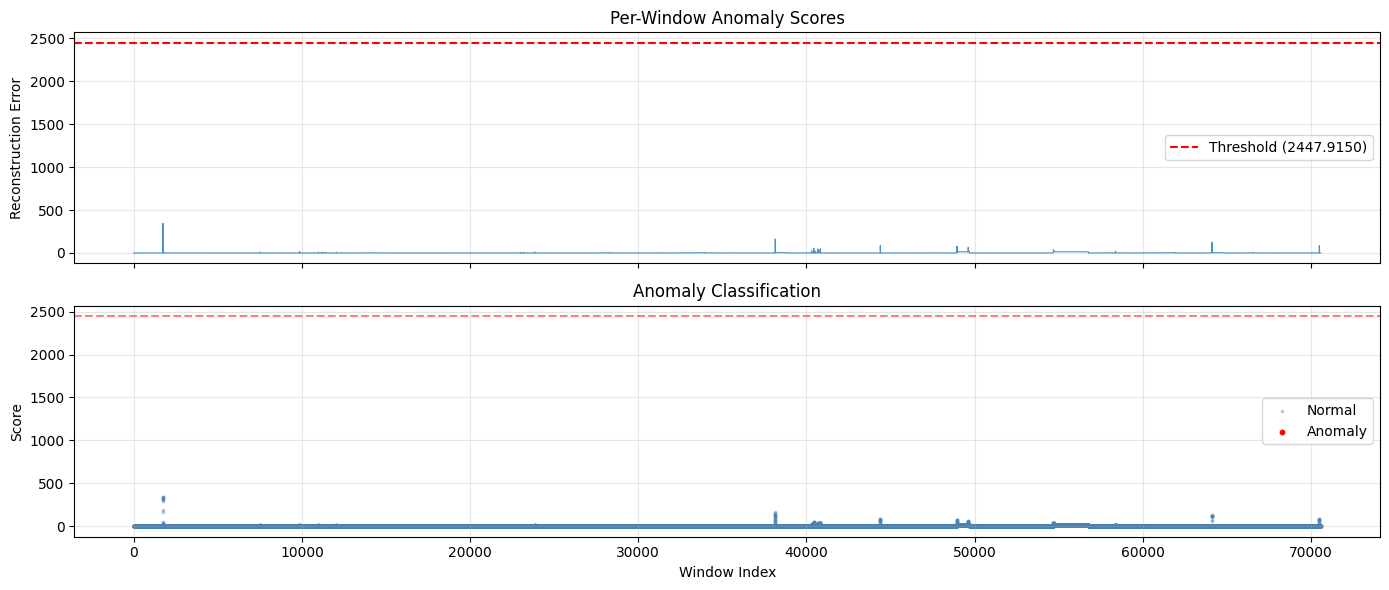

In [10]:
scores = results["scores"]
threshold = results["threshold"]
anomalies = results["anomalies"]

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(scores, linewidth=0.8, alpha=0.8)
axes[0].axhline(threshold, color="red", ls="--", label=f"Threshold ({threshold:.4f})")
axes[0].fill_between(
    range(len(scores)), scores, threshold,
    where=anomalies, alpha=0.3, color="red",
)
axes[0].set_ylabel("Reconstruction Error")
axes[0].set_title("Per-Window Anomaly Scores")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].scatter(
    np.where(~anomalies)[0], scores[~anomalies],
    c="steelblue", s=3, alpha=0.3, label="Normal",
)
axes[1].scatter(
    np.where(anomalies)[0], scores[anomalies],
    c="red", s=10, label="Anomaly",
)
axes[1].axhline(threshold, color="red", ls="--", alpha=0.5)
axes[1].set_xlabel("Window Index")
axes[1].set_ylabel("Score")
axes[1].set_title("Anomaly Classification")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

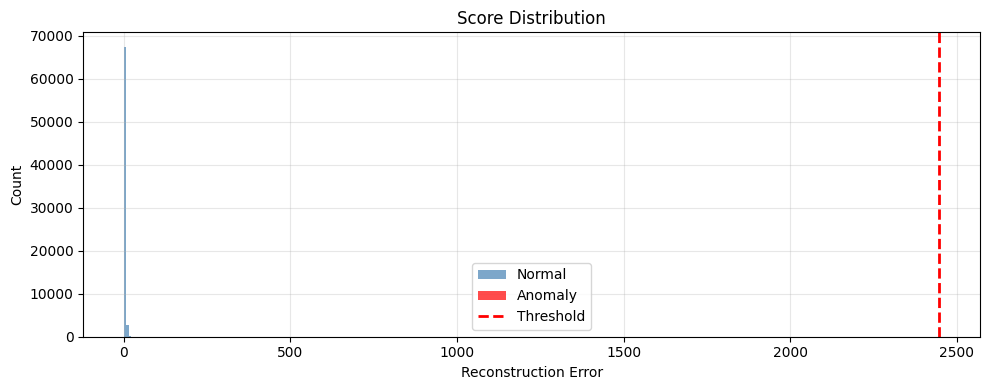

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(scores[~anomalies], bins=50, alpha=0.7, label="Normal", color="steelblue")
ax.hist(scores[anomalies], bins=20, alpha=0.7, label="Anomaly", color="red")
ax.axvline(threshold, color="red", ls="--", lw=2, label="Threshold")
ax.set_xlabel("Reconstruction Error")
ax.set_ylabel("Count")
ax.set_title("Score Distribution")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()